In [1]:
# Not required in Colab, but in case you're using Jupyter
# !pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns




In [13]:

# Load the CSV
df = pd.read_csv("UpdatedResumeDataSet.csv")
print(df.keys())

# Show the first few rows
df.head()

Index(['Category', 'Resume'], dtype='object')


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_resume'] = df['Resume'].apply(clean_text)

In [4]:
job_description = """
GenC - Job description:

Understand business requirements, raise clarifications, create documents
Develop, maintain, test, debug and deploy code as per the requirement specifications
Understand the data requirements and develop test scenarios
Understand the Agile application development environment, deliverables due and follow the SDLC
Create low level design for components
Identify and prioritize tasks to meet deadlines. Proactively address issues and work on mitigating points of failure
Take ownership to deliver on goals specified in a timely and efficient manner
Participate as a member of project team in meetings and technical sessions to develop reliable, cost effective and high-quality solutions
Continuously upskill/reskill and cross skill to scale up to new technologies
Possess excellent communication skills.
Ability to work collaboratively in a team environment.
"""

job_description_clean = clean_text(job_description)

In [5]:
# Combine resume corpus and job description
corpus = df['cleaned_resume'].tolist() + [job_description_clean]

# Create TF-IDF matrix
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(corpus)

# Split into resumes and job description vectors
resume_vectors = tfidf_matrix[:-1]
job_vector = tfidf_matrix[-1]

In [6]:
# Compare each resume with the job description
similarity_scores = cosine_similarity(job_vector, resume_vectors).flatten()

# Add to DataFrame
df['similarity_score'] = similarity_scores

In [7]:
# Top 10 resumes sorted by similarity
top_matches = df.sort_values(by='similarity_score', ascending=False).head(10)

# Show important columns
top_matches[['Category', 'similarity_score']].style.background_gradient(cmap='Blues')


,Category,similarity_score
406,Business Analyst,0.152900
414,Business Analyst,0.152900
428,Business Analyst,0.152900
424,Business Analyst,0.152900
420,Business Analyst,0.152900
410,Business Analyst,0.152900
215,Mechanical Engineer,0.135336
190,Mechanical Engineer,0.135336
195,Mechanical Engineer,0.135336
205,Mechanical Engineer,0.135336


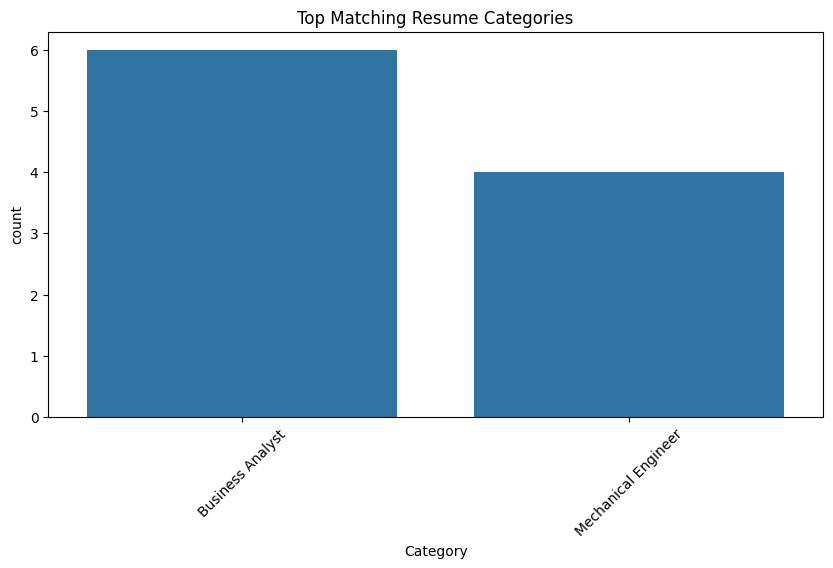

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(data=top_matches, x='Category')
plt.title("Top Matching Resume Categories")
plt.xticks(rotation=45)
plt.show()


In [9]:
top_selected = df.sort_values(by='similarity_score', ascending=False).head(10)

# View selected candidates
top_selected[['Category', 'similarity_score', 'Resume']].head()

,Category,similarity_score,Resume
406,Business Analyst,0.1529,IT Skills: Area Exposure Modeling Tool: Bizagi...
414,Business Analyst,0.1529,IT Skills: Area Exposure Modeling Tool: Bizagi...
428,Business Analyst,0.1529,IT Skills: Area Exposure Modeling Tool: Bizagi...
424,Business Analyst,0.1529,IT Skills: Area Exposure Modeling Tool: Bizagi...
420,Business Analyst,0.1529,IT Skills: Area Exposure Modeling Tool: Bizagi...


In [10]:
# Set a threshold score (adjust as needed)
threshold = 0.3
selected_candidates = df[df['similarity_score'] >= threshold]

# View selected
selected_candidates[['Category', 'similarity_score']].sort_values(by='similarity_score', ascending=False)


,Category,similarity_score


In [11]:
# Get top resume per category
top_by_category = df.sort_values(by='similarity_score', ascending=False).groupby('Category').head(1)

top_by_category[['Category', 'similarity_score']]

,Category,similarity_score
406,Business Analyst,0.152900
215,Mechanical Engineer,0.135336
458,Automation Testing,0.132573
708,PMO,0.132263
604,DevOps Engineer,0.106829
3,Data Science,0.103666
937,Testing,0.101754
511,Operations Manager,0.096625
719,Database,0.090097
802,ETL Developer,0.088757


In [12]:
# # Save selected resumes to a CSV file
# selected_candidates.to_csv('SelectedResumes.csv', index=False)

# # Download in Colab
# from google.colab import files
# files.download('SelectedResumes.csv')